## Registered Users

In [7]:
import boto3
import pandas as pd
from boto3.dynamodb.conditions import Attr
from datetime import datetime

# 1. Configuración de la sesión
# Si usas perfiles locales, añade profile_name='tu-perfil'
dynamodb = boto3.resource('dynamodb', region_name='us-east-1') 
table = dynamodb.Table('user_profiles')

# 2. Escaneo de la tabla
# Nota: .scan() es costoso en tablas gigantes, pero ideal para inspección rápida
response = table.scan()
items = response.get('Items', [])

# 3. Manejo de paginación (por si tienes más de 1MB de datos)
while 'LastEvaluatedKey' in response:
    response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
    items.extend(response.get('Items', []))

# 4. Visualización en Pandas
df = pd.DataFrame(items)

# Reordenar columnas para que el ID aparezca primero (opcional)
if not df.empty:
    cols = df.columns.tolist()
    # Cambia 'user_id' por tu Partition Key real si es distinta
    if 'user_id' in cols:
        cols.insert(0, cols.pop(cols.index('user_id')))
        df = df[cols]

print(f"Total de registros encontrados: {len(df)}")
df["creation_timestamp"] = df["user_id"].apply(lambda x: int(x.split("_")[1])) # Muestra las primeras 5 filas
df["login_date"] = df["creation_timestamp"].apply(lambda x: datetime.fromtimestamp(int(x)/1000).strftime('%d/%m/%Y %H:%M:%S')) # Muestra las primeras 5 filas

df = df.sort_values(by="creation_timestamp", ascending=False)
df

Total de registros encontrados: 27


,user_id,city,nickname,fcm_token,urban_context,country,gender,age,creation_timestamp,login_date
25,6e1f82b7e310f761_1772854111379,NaN,NaN,fQqWv_ZoQtizi12IDwlb2G:APA91bE4WqiiVvIXjcRzGz9...,NaN,NaN,NaN,NaN,1772854111379,07/03/2026 00:28:31
22,2f31ffd33f9d7ea6_1772829901686,Oslo,Bunny,cYOaxfLzQqCAkqtJai-VNA:APA91bEZahD_ps440bSvDOU...,Suburbs,Norway,Female,31,1772829901686,06/03/2026 17:45:01
6,2f31ffd33f9d7ea6_1772829752319,NaN,NaN,csDWYQ2rQHqlof8cndwiL8:APA91bElVb-dyymTY07IVNO...,NaN,NaN,NaN,NaN,1772829752319,06/03/2026 17:42:32
2,8397dcccd645feee_1772828065036,rosario,lucasbaezm9,cVqD_WiqQHiEsiR0fnwLro:APA91bFaGi9eLiIB4zPX9zu...,City,Argentina,Male,30,1772828065036,06/03/2026 17:14:25
13,8397dcccd645feee_1772828065035,NaN,NaN,cVqD_WiqQHiEsiR0fnwLro:APA91bFaGi9eLiIB4zPX9zu...,NaN,NaN,NaN,NaN,1772828065035,06/03/2026 17:14:25
16,8397dcccd645feee_1772827927596,Rosario,lucasbm9,eOYvsNEtT3qCfQFkvsXU41:APA91bFYmoS3GTyvfiGem_J...,Countryside,Argentina,Male,28,1772827927596,06/03/2026 17:12:07
7,568e488267ffc3ad_1772827316686,Bernal,Lu,cedoxuv4STKMH1sCqSwL5W:APA91bH8cp2T_ZvhQrLOi5_...,Suburbs,Argentina,Female,27,1772827316686,06/03/2026 17:01:56
3,8397dcccd645feee_1772825839634,Rosario,lucasbm8,fGe9wmBrQrmSuJe6uJUoNK:APA91bEdin1rjVeZrBv3Gn_...,City,Argentina,Male,29,1772825839634,06/03/2026 16:37:19
20,2f31ffd33f9d7ea6_1772644898073,Oslo,bunny,d9vubNHMTzO0CzUrSEhLHK:APA91bHiYxMxoyH-eEkWKJE...,Suburbs,Norway,Female,31,1772644898073,04/03/2026 14:21:38
10,568e488267ffc3ad_1772640987523,Bernal,Lu,NaN,Suburbs,Argentina,Female,27,1772640987523,04/03/2026 13:16:27


## User Activity

In [2]:
import boto3
import pandas as pd
from boto3.dynamodb.conditions import Attr
from datetime import datetime

# 1. Configuración de la sesión
# Si usas perfiles locales, añade profile_name='tu-perfil'
dynamodb = boto3.resource('dynamodb', region_name='us-east-1') 
table = dynamodb.Table('user_activity')

# 2. Escaneo de la tabla
# Nota: .scan() es costoso en tablas gigantes, pero ideal para inspección rápida
response = table.scan()
items = response.get('Items', [])

# 3. Manejo de paginación (por si tienes más de 1MB de datos)
while 'LastEvaluatedKey' in response:
    response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
    items.extend(response.get('Items', []))

# 4. Visualización en Pandas
df = pd.DataFrame(items)

# Reordenar columnas para que el ID aparezca primero (opcional)
if not df.empty:
    cols = df.columns.tolist()
    # Cambia 'user_id' por tu Partition Key real si es distinta
    if 'user_id' in cols:
        cols.insert(0, cols.pop(cols.index('user_id')))
        df = df[cols]

print(f"Total de registros encontrados: {len(df)}")
df["time"] = df["timestamp"].apply(lambda x: datetime.fromtimestamp(int(x)).strftime('%d/%m/%Y %H:%M:%S')) # Muestra las primeras 5 filas
df.tail(15)

Total de registros encontrados: 78


,user_id,avg_speed_kmh,activity,latitude,longitude,timestamp,still_min,on_foot_min,on_bicycle_min,walking_min,unknown_min,in_vehicle_min,running_min,time
63,8397dcccd645feee_1772236859296,NaN,NaN,NaN,NaN,1772331960,0,0,0,0,0,0,0,28/02/2026 23:26:00
64,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772318144,0,0,0,0,0,0,0,28/02/2026 19:35:44
65,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772319045,0,0,0,0,15,0,0,28/02/2026 19:50:45
66,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772319945,0,0,0,0,15,0,0,28/02/2026 20:05:45
67,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772320845,0,0,0,0,15,0,0,28/02/2026 20:20:45
68,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772321745,0,0,0,0,15,0,0,28/02/2026 20:35:45
69,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772322878,0,0,0,0,18,0,0,28/02/2026 20:54:38
70,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772323798,0,0,0,0,15,0,0,28/02/2026 21:09:58
71,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772324992,0,0,0,0,19,0,0,28/02/2026 21:29:52
72,8397dcccd645feee_1772317242964,NaN,NaN,NaN,NaN,1772325892,0,0,0,0,15,0,0,28/02/2026 21:44:52


## Sacar modo Admin y modo User

-Corregir pasos - Ni bien se instala
- Gender - Sin select
- Default - Norway

- Priorizar ecuacion -> Vida dependientente de velocidad. El umbral esta en 35 km/h

En la version Admin - Dos pestañas -> 
- Gato con diferentes estadios
- Personalizacion de gato

## Steps y vel media

In [8]:
import pandas as pd
import numpy as np

def agregar_velocidad(df):
    try:
        # 1. Forzamos conversión a float (adiós Decimal/Strings) y ordenamos
        df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
        df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
        df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
        
        df = df.sort_values('timestamp').reset_index(drop=True)

        # 2. Limpieza de NaNs para el cálculo (evita propagación del error)
        lat_clean = df['latitude'].ffill().bfill()
        lon_clean = df['longitude'].ffill().bfill()

        # 3. Preparar coordenadas (Rellenamos el shift con el valor actual para que la resta sea 0)
        lat1 = np.radians(lat_clean.shift(1).fillna(lat_clean))
        lon1 = np.radians(lon_clean.shift(1).fillna(lon_clean))
        lat2 = np.radians(lat_clean)
        lon2 = np.radians(lon_clean)

        # 4. Haversine (Distancia en metros)
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        distancia_m = 6371000 * (2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))))

        # 5. Tiempo y Velocidad
        delta_t = df['timestamp'].diff().abs().fillna(0)
        
        # Evitamos división por cero si el timestamp es el mismo
        df["distancia_m"] = distancia_m
        df['velocidad_ms'] = np.where(delta_t > 0, distancia_m / delta_t, 0.0)
        df['velocidad_kmh'] = df['velocidad_ms'] * 3.6

    except Exception as e:
        print(f"Error procesando datos: {e}")
        df['velocidad_ms'] = np.nan
        df['velocidad_kmh'] = np.nan

    return df

import pandas as pd
import numpy as np

def agregar_geometria_y_velocidad(df, lat_ref=None, lon_ref=None):
    """
    Calcula velocidad (m/s, km/h) y coordenadas proyectadas (x, y) en metros.
    Si no se proveen lat_ref/lon_ref, se usa el primer punto del dataset como origen (0,0).
    """
    try:
        # 1. Forzamos conversión a float y ordenamos
        df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
        df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
        df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
        
        df = df.sort_values('timestamp').reset_index(drop=True)

        # 2. Limpieza de NaNs para el cálculo
        lat_clean = df['latitude'].ffill().bfill()
        lon_clean = df['longitude'].ffill().bfill()

        # 3. Preparar coordenadas en radianes
        lat_rad = np.radians(lat_clean)
        lon_rad = np.radians(lon_clean)
        
        # Definir punto de referencia para X e Y
        if lat_ref is None or lon_ref is None:
            lat0_rad = lat_rad.iloc[0]
            lon0_rad = lon_rad.iloc[0]
        else:
            lat0_rad = np.radians(lat_ref)
            lon0_rad = np.radians(lon_ref)

        # 4. Cálculo de X e Y (Proyección local en metros)
        R = 6371000  # Radio medio de la Tierra en metros
        df['x_m'] = R * (lon_rad - lon0_rad) * np.cos(lat0_rad)
        df['y_m'] = R * (lat_rad - lat0_rad)

        # 5. Haversine para Distancia entre puntos consecutivos
        lat1 = lat_rad.shift(1).fillna(lat_rad)
        lon1 = lon_rad.shift(1).fillna(lon_rad)
        
        dlat = lat_rad - lat1
        dlon = lon_rad - lon1
        
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat_rad) * np.sin(dlon/2)**2
        distancia_m = R * (2 * np.arcsin(np.sqrt(np.clip(a, 0, 1))))

        # 6. Tiempo y Velocidad
        delta_t = df['timestamp'].diff().abs().fillna(0)
        
        df["distancia_m"] = distancia_m
        df['velocidad_ms'] = np.where(delta_t > 0, distancia_m / delta_t, 0.0)
        df['velocidad_kmh'] = df['velocidad_ms'] * 3.6

    except Exception as e:
        print(f"Error procesando datos: {e}")
        df['x_m'] = np.nan
        df['y_m'] = np.nan
        df['velocidad_ms'] = np.nan
        df['velocidad_kmh'] = np.nan

    return df

In [35]:
import boto3
import pandas as pd
from boto3.dynamodb.conditions import Attr
from datetime import datetime


# 1. Configuración de la sesión
# Si usas perfiles locales, añade profile_name='tu-perfil'
dynamodb = boto3.resource('dynamodb', region_name='us-east-1') 
table = dynamodb.Table('user_steps')

# 2. Escaneo de la tabla
# Nota: .scan() es costoso en tablas gigantes, pero ideal para inspección rápida
response = table.scan()
items = response.get('Items', [])

# 3. Manejo de paginación (por si tienes más de 1MB de datos)
while 'LastEvaluatedKey' in response:
    response = table.scan(ExclusiveStartKey=response['LastEvaluatedKey'])
    items.extend(response.get('Items', []))

# 4. Visualización en Pandas
df = pd.DataFrame(items)

# Reordenar columnas para que el ID aparezca primero (opcional)
if not df.empty:
    cols = df.columns.tolist()
    # Cambia 'user_id' por tu Partition Key real si es distinta
    if 'user_id' in cols:
        cols.insert(0, cols.pop(cols.index('user_id')))
        df = df[cols]

print(f"Total de registros encontrados: {len(df)}")
df["timestamp"] = df["timestamp"].apply(lambda x: int(x))
df['dt_object'] = pd.to_datetime(df['timestamp'], unit='s')
df["mes_nro"] = df['dt_object'].dt.month
df["time"] = df["timestamp"].apply(lambda x: datetime.fromtimestamp(int(x)).strftime('%d/%m/%Y %H:%M:%S')) # Muestra las primeras 5 filas

df = agregar_geometria_y_velocidad(df)
df = df.sort_values(by = "timestamp", ascending = True)
df = df[df["latitude"].between(-35, -34) & df["longitude"].between(-59, -58)]

Total de registros encontrados: 4635


In [38]:
# Filtramos lo de marzo y vemos los users

df_marzo = df[df["mes_nro"] == 3]
df_marzo = df_marzo[df_marzo["velocidad_ms"]<100]

In [46]:
df_marzo.to_excel("datos_marzo.xlsx", index=False)

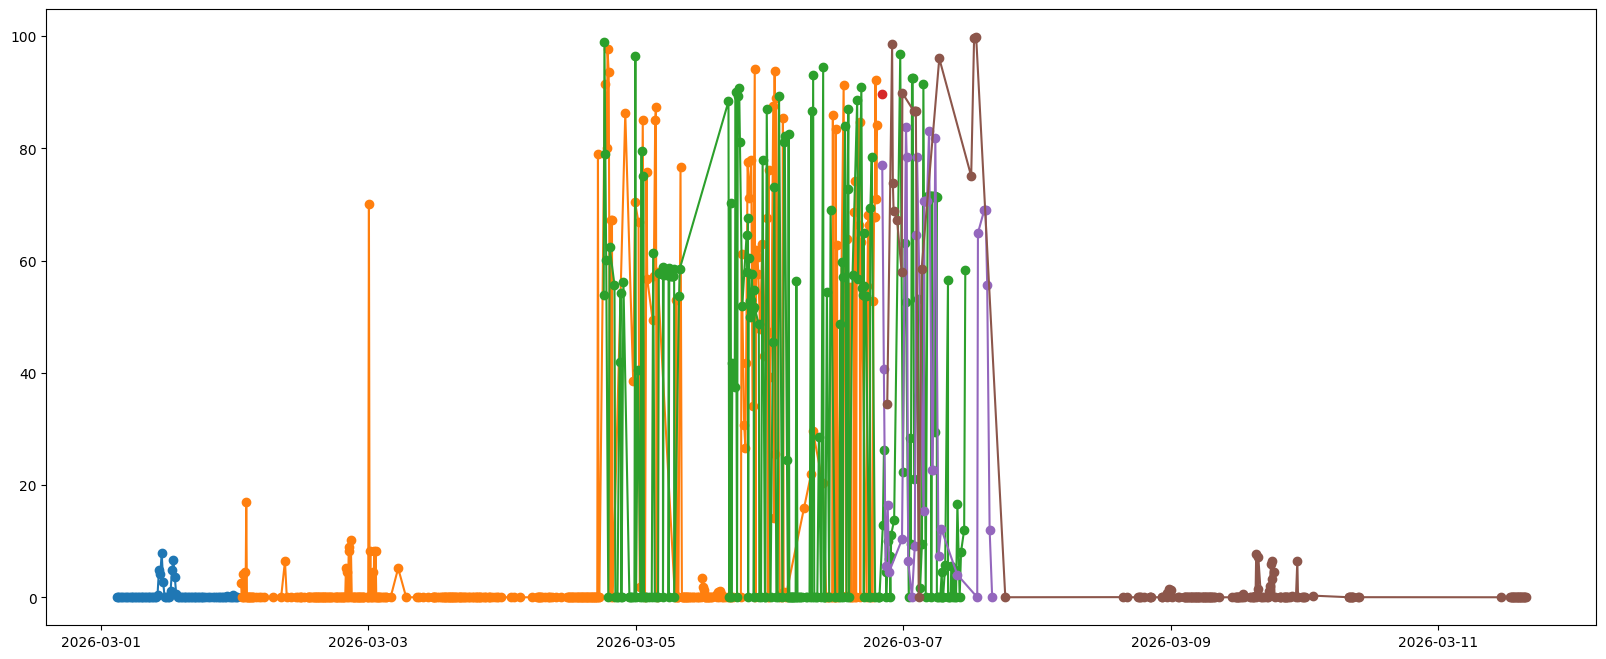

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize = (20,8))
for user in df_marzo["user_id"].unique():
    curr_df = df_marzo[df_marzo["user_id"] == user]
    plt.plot(curr_df["dt_object"], curr_df["velocidad_ms"], '-o')
    